In [14]:
# importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score

In [11]:
# loading data into frame
df = pd.read_csv('pcos_dataset.csv')
features = ['Age', 'BMI', 'Menstrual_Irregularity', 'Testosterone_Level(ng/dL)', 'Antral_Follicle_Count']

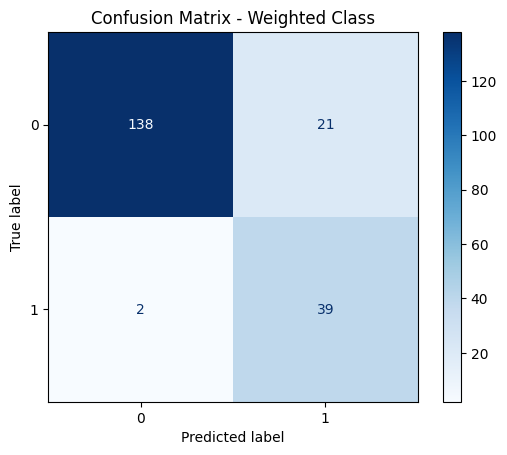

In [18]:
# running model again, this time weighing the minority class more
X = df[features]
y = df['PCOS_Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 19)

# establishing a class weight
model = LogisticRegression(class_weight='balanced') 
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# visualizing confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap="Blues")
plt.title('Confusion Matrix - Weighted Class')
plt.show()

In [15]:
# since the dataset is so imbalanced, weighing the minority class more helps with this
# there are other options to account for data imbalance, but I chose this one :)

In [16]:
# creating a table for eval metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [accuracy, precision, recall, f1]
}

metrics_df = pd.DataFrame(metrics_data)
display(metrics_df)

,Metric,Score
0,Accuracy,0.885000
1,Precision,0.650000
2,Recall,0.951220
3,F1-score,0.772277


In [ ]:
# now we have a recall of 95, which is pretty solid -- concerns for possible overfitting